In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/healthcare_dataset.csv.zip")

In [5]:
df


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [6]:
df.shape

(55500, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [8]:
df['Blood Type'].unique()

array(['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-'], dtype=object)

**PIE CHART**

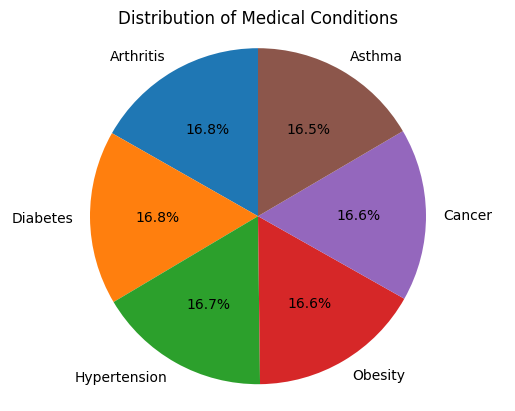

In [9]:
import matplotlib.pyplot as plt
type_of_condition = df['Medical Condition'].value_counts()

plt.pie(
    type_of_condition,
    labels=type_of_condition.index,
    autopct='%.1f%%',
    startangle=90
)
plt.title('Distribution of Medical Conditions')
plt.axis('equal')  # Ensures pie chart is a circle
plt.show()

**BAR CHAT**

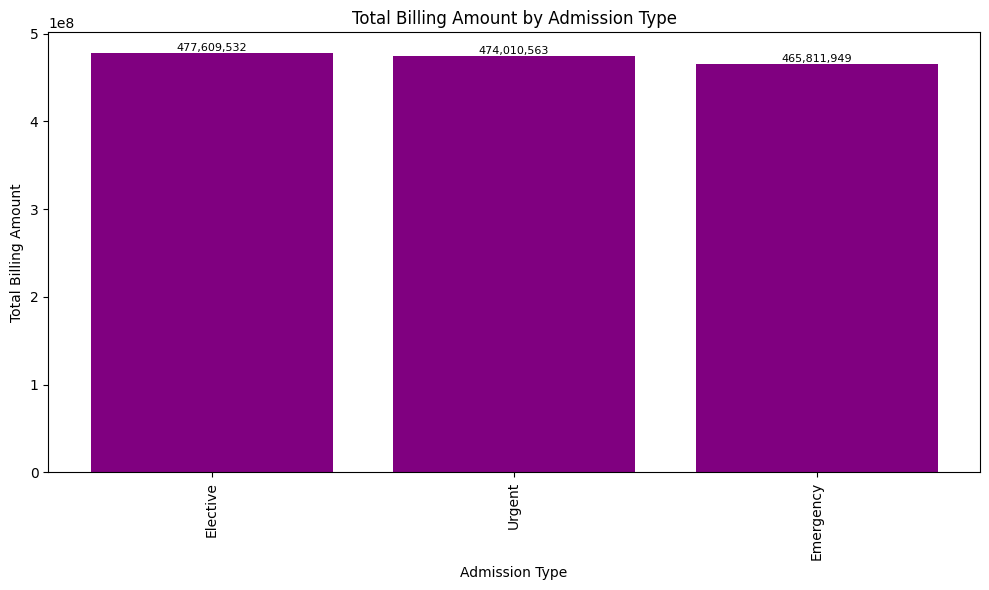

In [10]:
type_of_condition = df.groupby('Admission Type')['Billing Amount'].sum().sort_values(ascending=False)
#Set figure size
plt.figure(figsize=(10, 6))
# Create bar chart
bars = plt.bar(type_of_condition.index, type_of_condition.values, color='purple')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)
plt.xlabel('Admission Type')
plt.ylabel('Total Billing Amount')
plt.title('Total Billing Amount by Admission Type')
# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

DONUT CHART



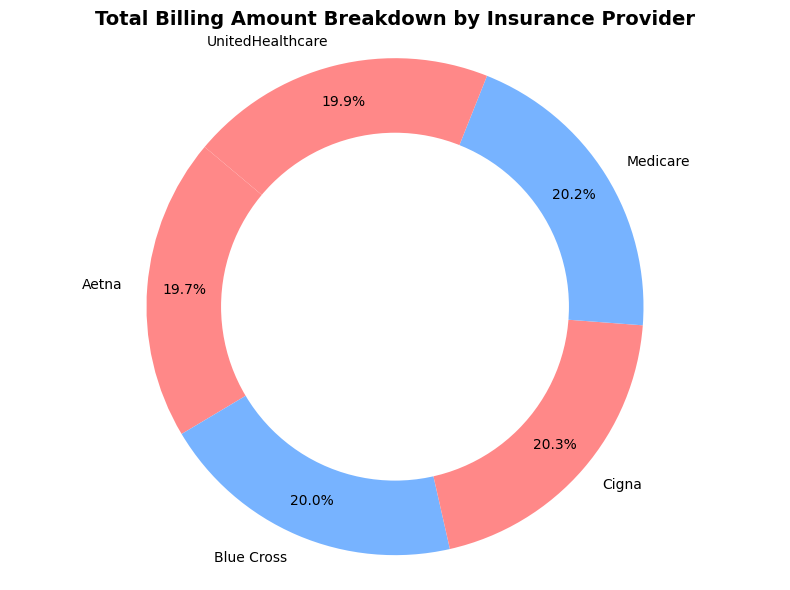

In [11]:
import matplotlib.pyplot as plt

cost_by_insurance = df.groupby('Insurance Provider')['Billing Amount'].sum()


plt.figure(figsize=(8, 6))
plt.pie(
    cost_by_insurance,
    labels=cost_by_insurance.index,
    autopct='%.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=['#Ff8888', '#77B3FF']
)


centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Total Billing Amount Breakdown by Insurance Provider', fontsize=14, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [12]:
# Convert date columns to datetime objects
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

/tmp/ipykernel_4790/3459178174.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date of Admission').size().plot(kind='line', marker='o', color='teal')


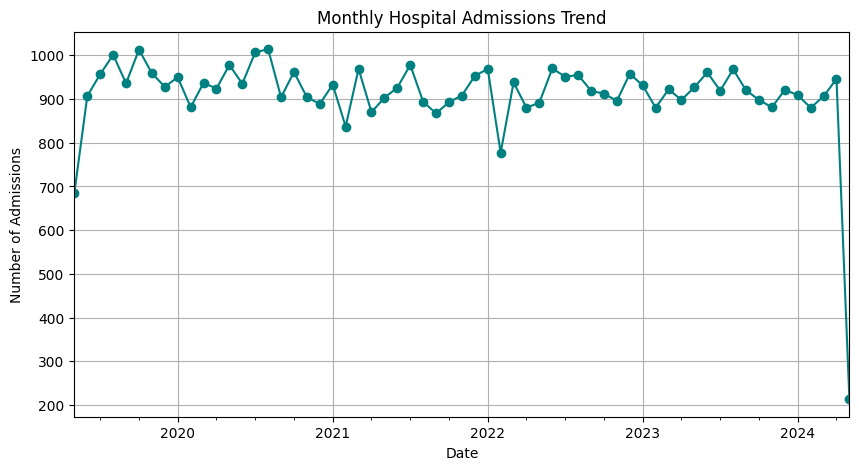

In [13]:
plt.figure(figsize=(10, 5))
# Resample by month to see the trend clearly
df.resample('M', on='Date of Admission').size().plot(kind='line', marker='o', color='teal')
plt.title('Monthly Hospital Admissions Trend')
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.grid(True)
plt.show()


/tmp/ipykernel_4790/2384116028.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Medical Condition', order=df['Medical Condition'].value_counts().index, palette='viridis')


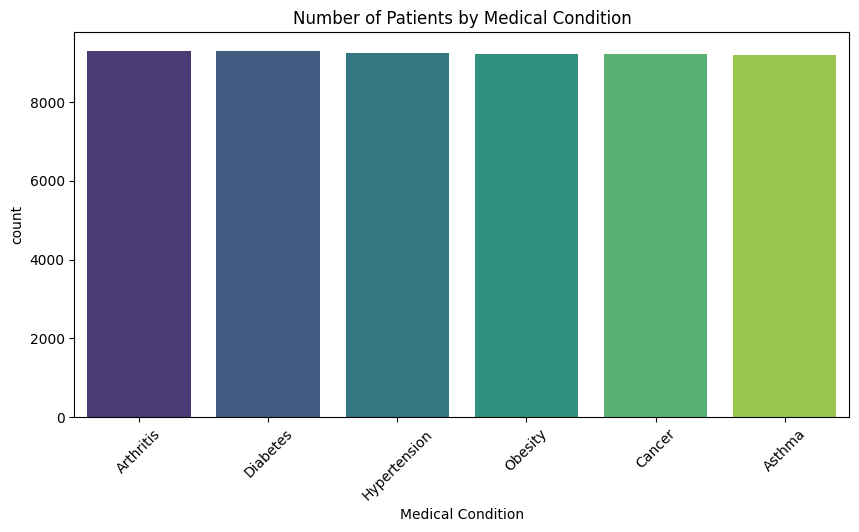

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Medical Condition', order=df['Medical Condition'].value_counts().index, palette='viridis')
plt.title('Number of Patients by Medical Condition')
plt.xticks(rotation=45)
plt.show()


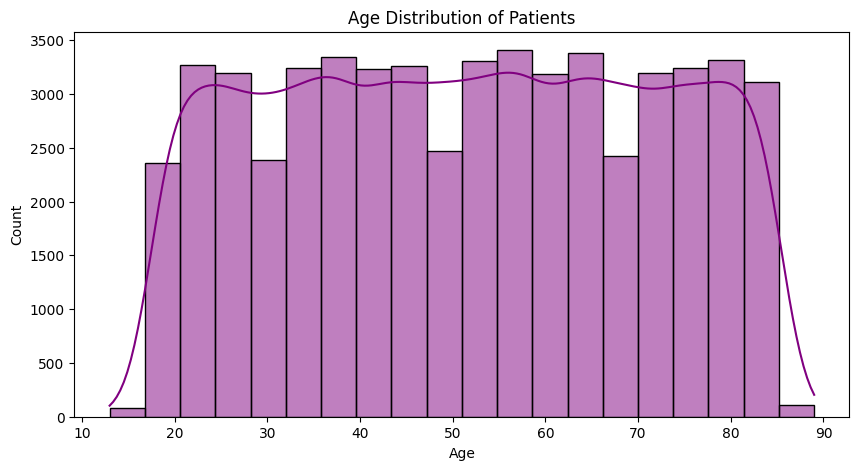

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='purple')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


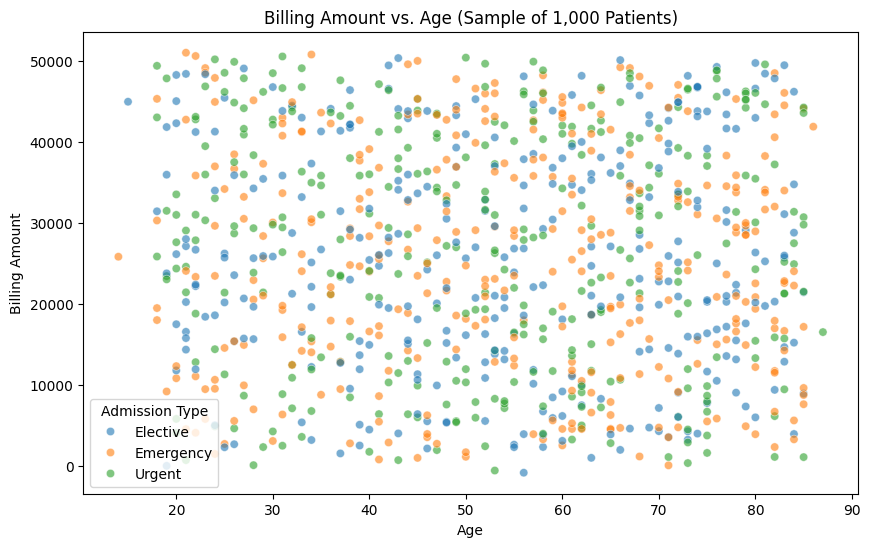

In [16]:
plt.figure(figsize=(10, 6))
# Sample 1000 points so the scatter plot doesn't become overcrowded
sns.scatterplot(data=df.sample(1000), x='Age', y='Billing Amount', hue='Admission Type', alpha=0.6)
plt.title('Billing Amount vs. Age (Sample of 1,000 Patients)')
plt.show()


/tmp/ipykernel_4790/3850457934.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Admission Type', y='Billing Amount', ax=axes[0], palette='pastel')
/tmp/ipykernel_4790/3850457934.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Admission Type', y='Billing Amount', ax=axes[1], palette='pastel')


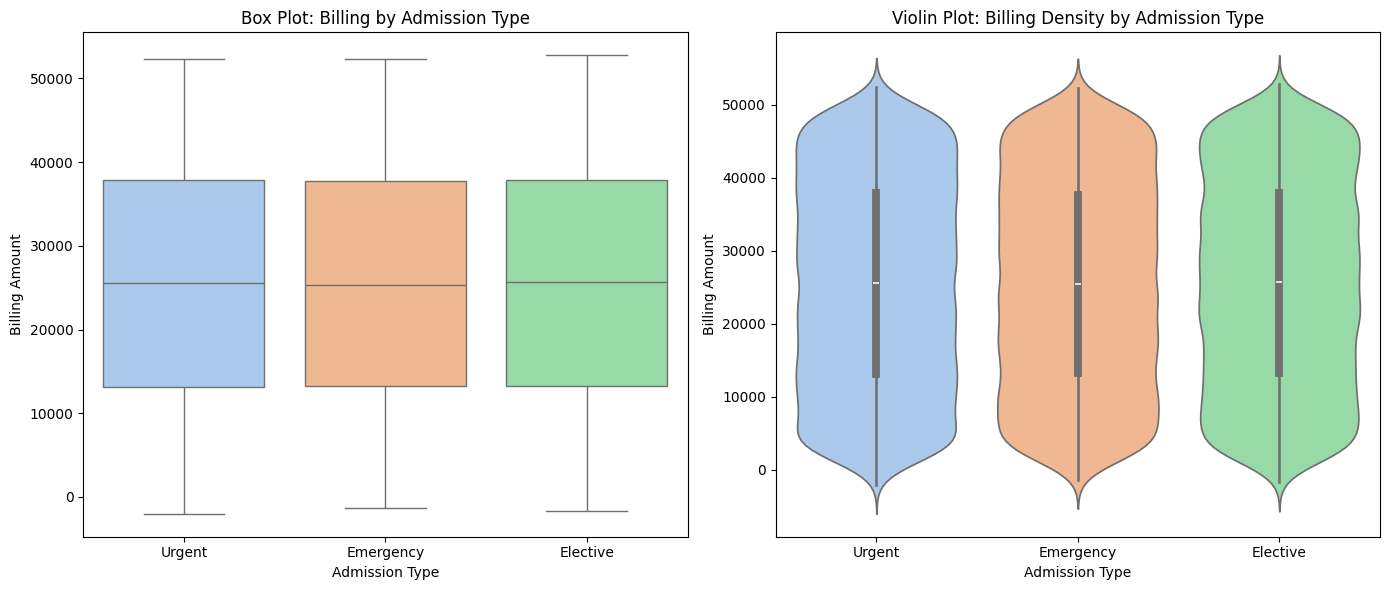

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot
sns.boxplot(data=df, x='Admission Type', y='Billing Amount', ax=axes[0], palette='pastel')
axes[0].set_title('Box Plot: Billing by Admission Type')

# Violin Plot
sns.violinplot(data=df, x='Admission Type', y='Billing Amount', ax=axes[1], palette='pastel')
axes[1].set_title('Violin Plot: Billing Density by Admission Type')

plt.tight_layout()
plt.show()


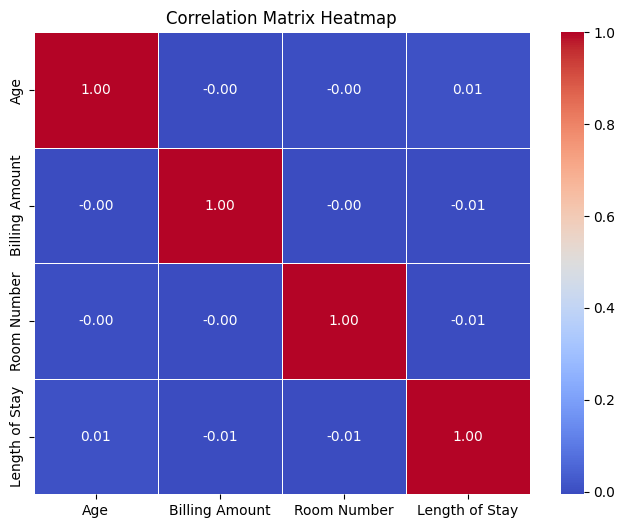

In [18]:
plt.figure(figsize=(8, 6))
# Calculate correlation among available numeric features
corr_matrix = df[['Age', 'Billing Amount', 'Room Number', 'Length of Stay']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


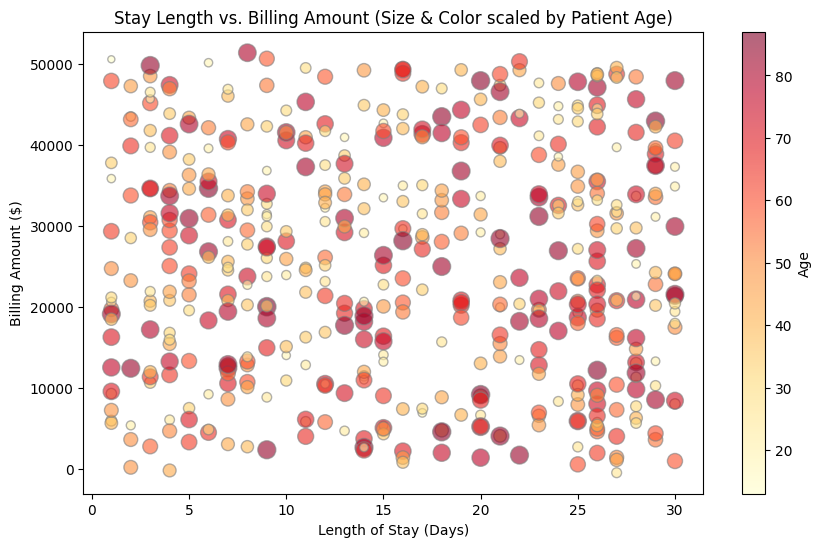

In [19]:
plt.figure(figsize=(10, 6))
sample_df = df.sample(500) # Sampled for visual clarity

# Scatter plot where 's' dictates the bubble size based on the patient's age
plt.scatter(sample_df['Length of Stay'], sample_df['Billing Amount'],
            s=sample_df['Age']*2, c=sample_df['Age'], cmap='YlOrRd', alpha=0.6, edgecolors="grey")

plt.title('Stay Length vs. Billing Amount (Size & Color scaled by Patient Age)')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount ($)')
plt.colorbar(label='Age')
plt.show()


In [20]:
import folium
from folium.plugins import MarkerCluster

# Create a base map centered generally
hospital_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)
marker_cluster = MarkerCluster().add_to(hospital_map)

# Mocking coordinates for top 10 unique hospitals in the frame for display purposes
top_hospitals = df['Hospital'].value_counts().head(10).index
import random

for hospital in top_hospitals:
    # Generates safe random plot markers to mimic geo-tagged facilities
    lat, lon = random.uniform(30, 45), random.uniform(-120, -75)
    cases = int(df[df['Hospital'] == hospital].shape[0])
    folium.Marker(
        location=[lat, lon],
        popup=f"{hospital}: {cases} Patients",
        icon=folium.Icon(color="red", icon="plus")
    ).add_to(marker_cluster)

# To view this map in a notebook, type: hospital_map


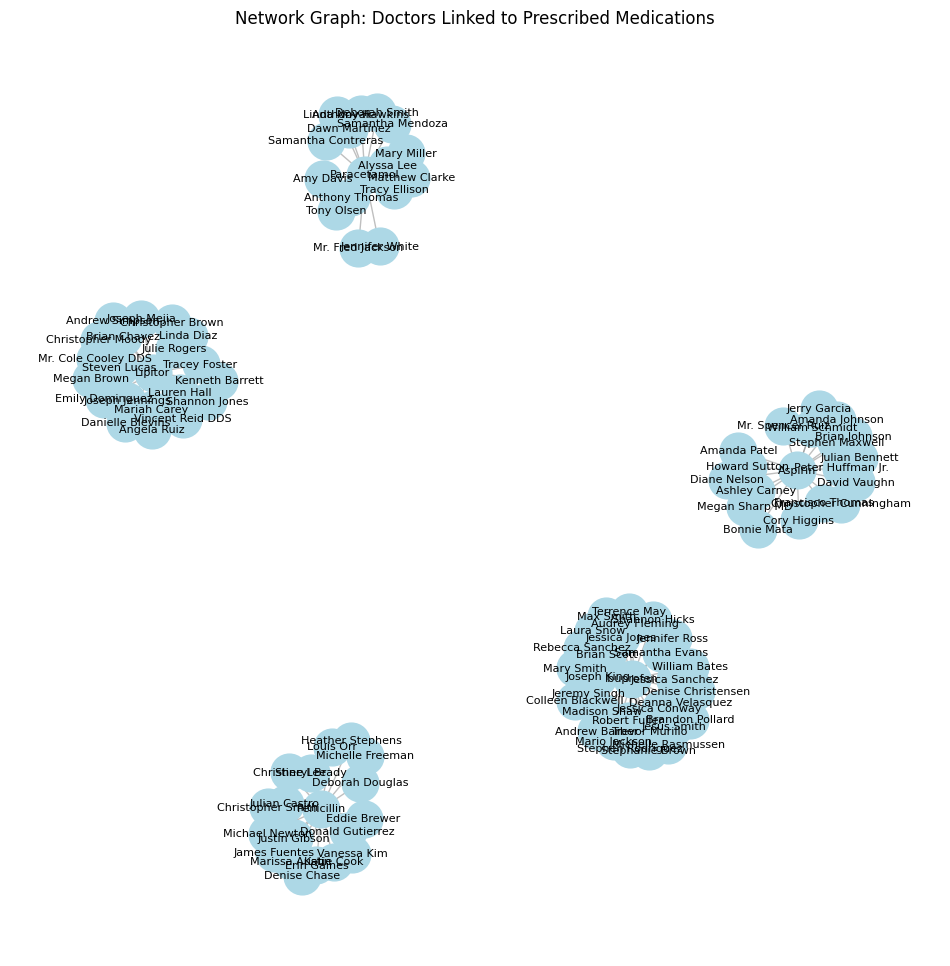

In [21]:
import networkx as nx

plt.figure(figsize=(12, 12))
# Sample relationship pairs between a subset of Doctors and Medications
network_df = df.sample(100)[['Doctor', 'Medication']]

# Build the graph structure from the dataframe layout
G = nx.from_pandas_edgelist(network_df, source='Doctor', target='Medication')

# Plot layout
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title('Network Graph: Doctors Linked to Prescribed Medications')
plt.axis('off')
plt.show()
